# EDA is the process of understanding your dataset by looking at it, summarizing it, and visualizing patterns before applying any machine learning model.

### Import Libraries
 In this step, we are importing all the necessary Python libraries that we will use in this project.
 - numpy and pandas: for data manipulation
 - seaborn and matplotlib: for data visualization
 - sklearn modules: for preprocessing and train-test split for machine learning

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load the dataset `flight.csv`


In [ ]:
df=pd.read_csv("Data_Train.csv")

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


# Exploratory Data Analysis (EDA)
###  In this step, we will explore the data to understand patterns and relationships.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [ ]:
df.isnull()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
10678,False,False,False,False,False,False,False,False,False,False,False
10679,False,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,False,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
df=df.dropna()

In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [ ]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

### Count plot for airlines to see which airlines operate most flights.


<Axes: xlabel='Airline', ylabel='count'>

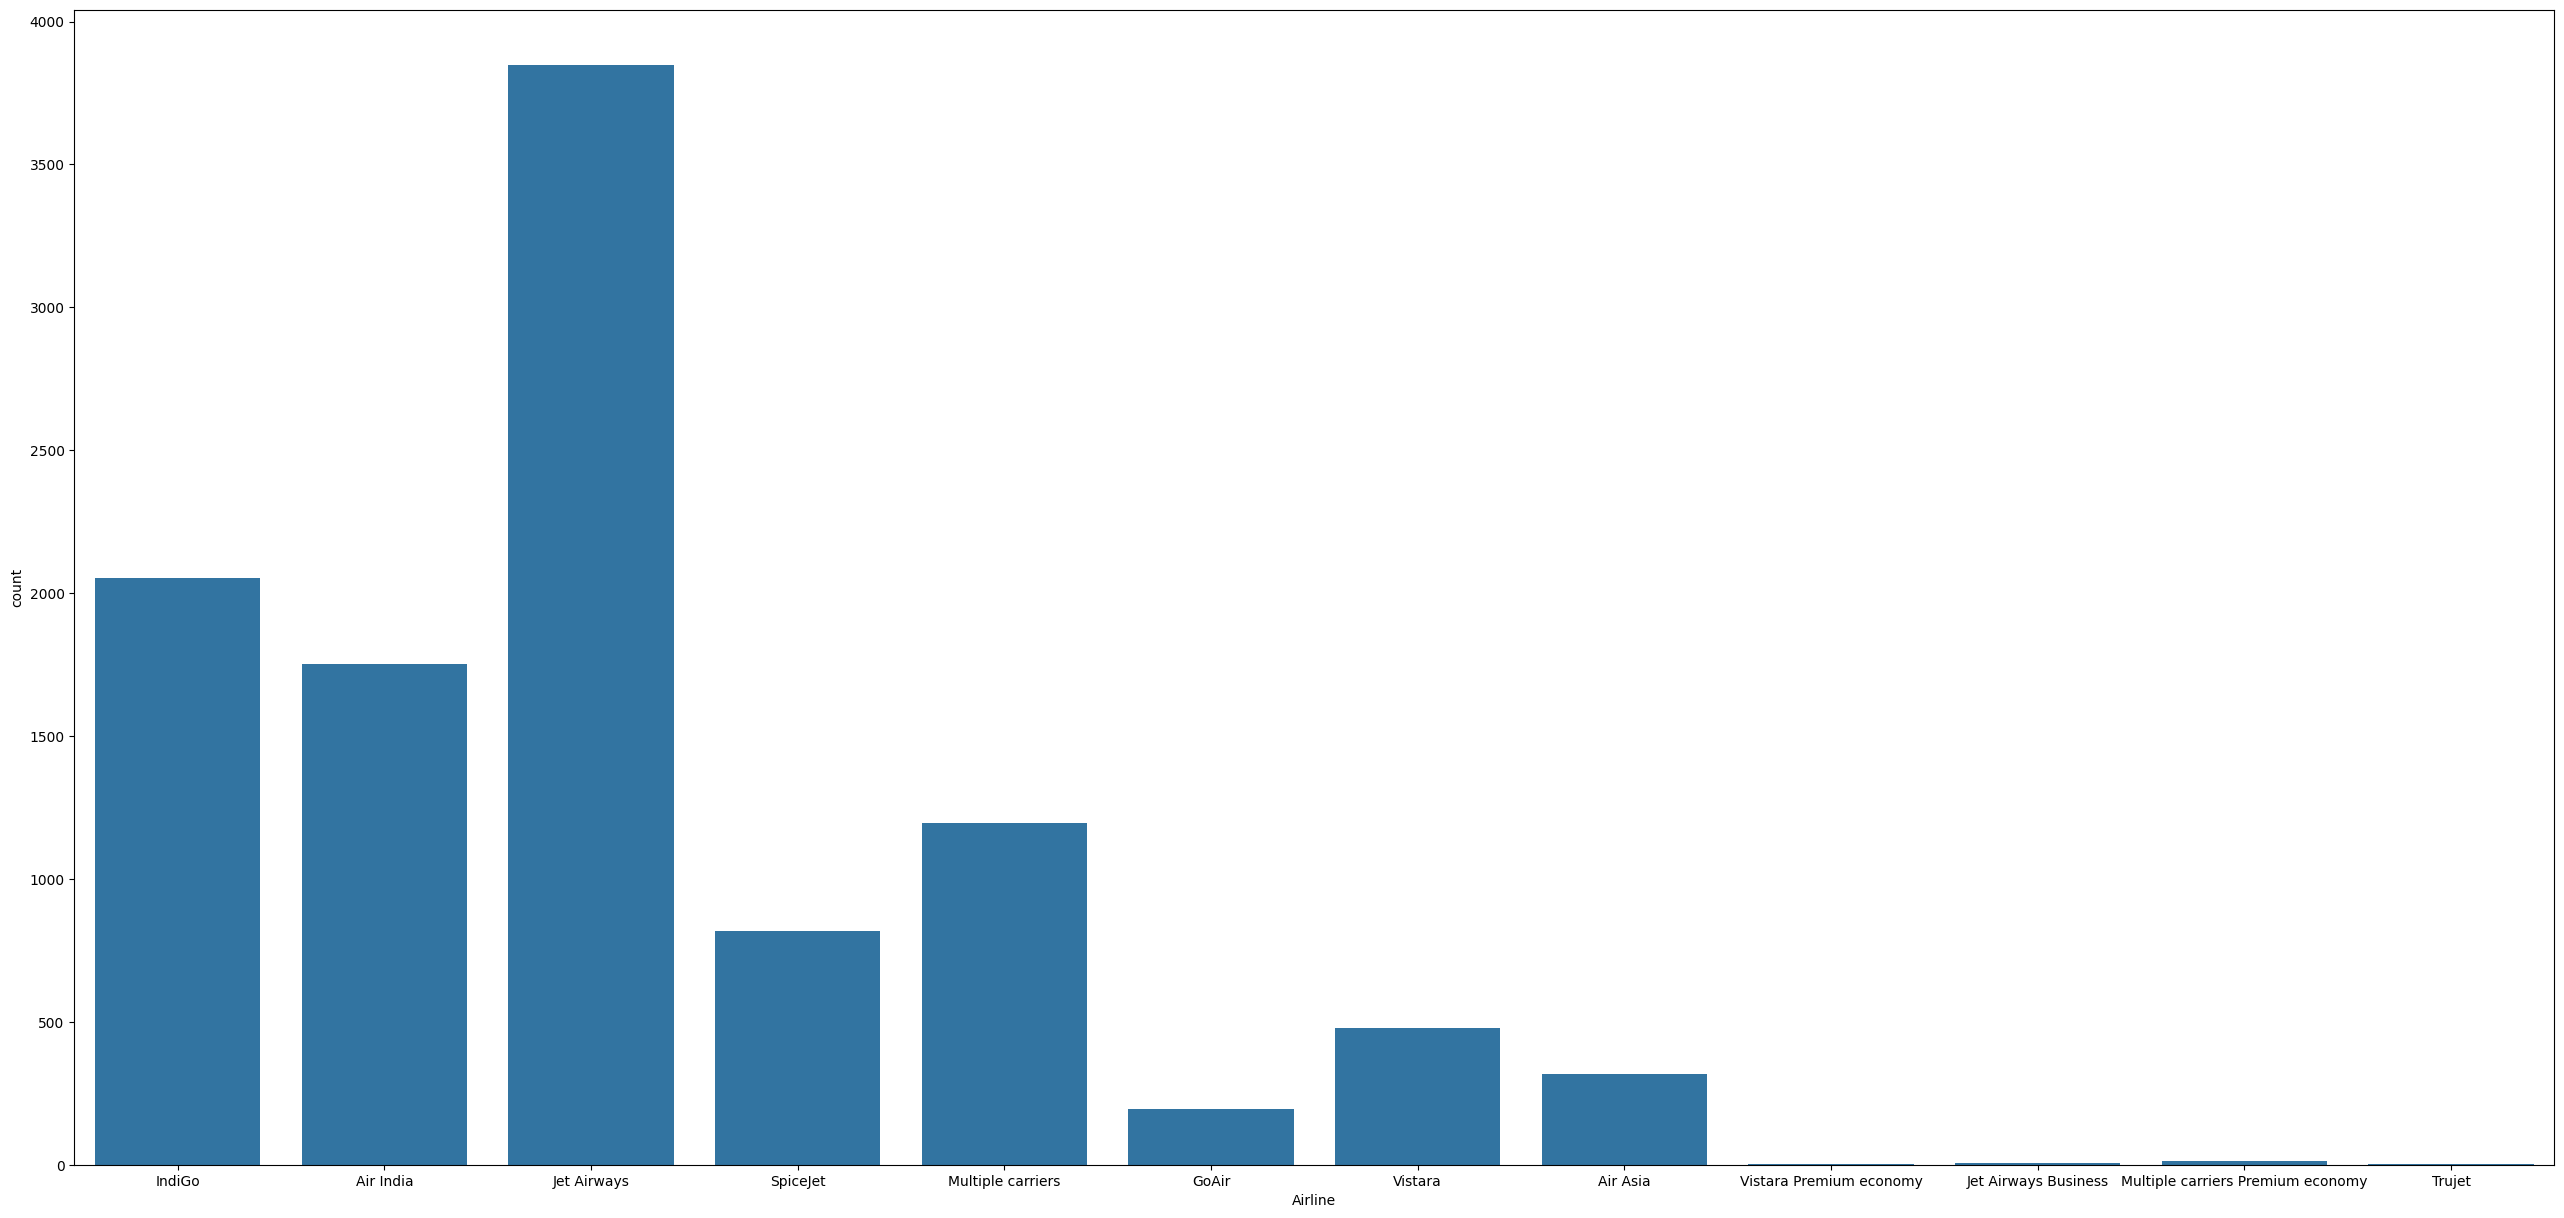

In [ ]:
plt.figure(figsize=(32,15),dpi=100)
sns.countplot(x=df['Airline'])

### Visualizing Total Stops
Count plot for total stops to see how many flights are non-stop, 1 stop, etc.


<Axes: xlabel='Total_Stops', ylabel='count'>

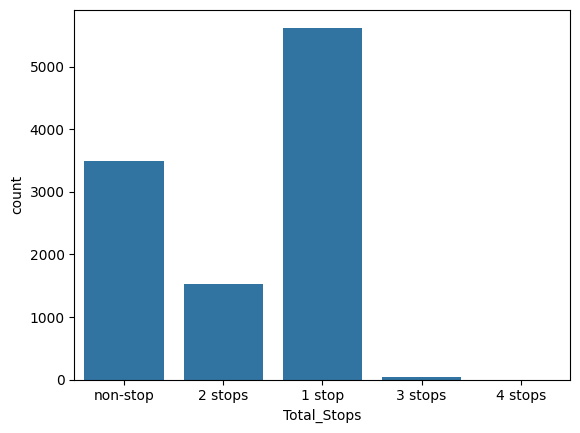

In [ ]:
sns.countplot(x=df['Total_Stops'])

### Histogram for Price to see how ticket prices are spread.


<Axes: xlabel='Price', ylabel='Count'>

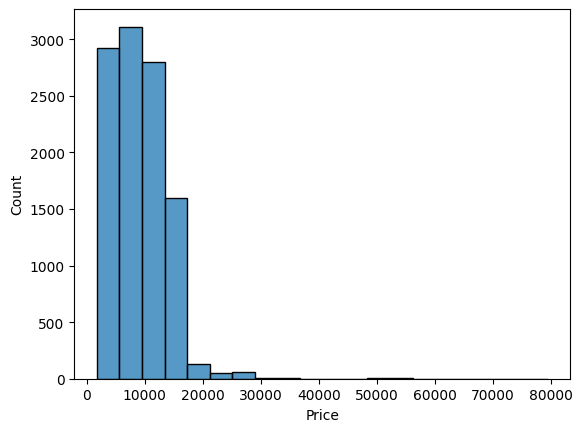

In [ ]:
sns.histplot(df['Price'],bins=20)

<Axes: xlabel='Price'>

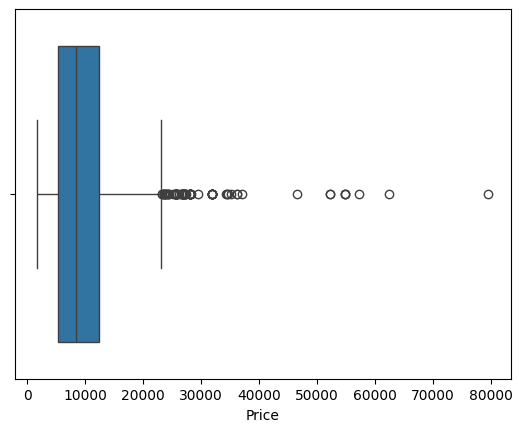

In [ ]:
sns.boxplot(x=df['Price'])

In [ ]:
q3=df['Price'].quantile(0.75)
q1=df['Price'].quantile(0.25)
iqr=q3-q1
l_bound=q1-1.5*iqr
u_bound=q3+1.5*iqr
print(q1,q3,iqr,l_bound,u_bound)

5277.0 12373.0 7096.0 -5367.0 23017.0


In [ ]:
df_clean=df[(df['Price']>=l_bound) & (df['Price']<=u_bound)]
df_clean

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


# Feature Engineering
### Feature engineering is the process of creating new features or transforming existing ones in your dataset to make them more useful for a machine learning model.

#### Extract Day, Month, and Year from the journey date.
### This is useful because flight prices can vary by month or day of the month.


### Drop columns which are not useful

In [ ]:
df['Day']=df['Date_of_Journey'].str.split('/').str[0]
df['Month']=df['Date_of_Journey'].str.split('/').str[1]
df['Year']=df['Date_of_Journey'].str.split('/').str[2]

In [ ]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,01,03,2019


### Extract arrival hour and minute as separate numerical features.
### Arrival time may affect pricing, especially if flights arrive at peak or late-night hours.

In [ ]:
df['temp'] = df['Arrival_Time'].str.split().str[0]
df['temp'].str.split(':')[0]
df['temp'].str.split(':')[1]

['13', '15']

In [ ]:
df['Arrival_Hours']=df['Arrival_Time'].str.split(':').str[0].astype(int)
df['Arrival_Mins']=df['Arrival_Time'].str.split(':').str[1]
# df.head()

In [ ]:
df.drop('Arrival_Time',axis=1,inplace=True)
df.drop('Date_of_Journey',axis=1,inplace=True)

In [ ]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,temp,Arrival_Hours,Arrival_Mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897,24,03,2019,01:10,1,10 22 Mar
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662,1,05,2019,13:15,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882,9,06,2019,04:25,4,25 10 Jun
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218,12,05,2019,23:30,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302,01,03,2019,21:35,21,35


#### Convert the number of stops from text to numerical values.
#### More stops usually mean cheaper flights but longer durations.

In [ ]:
df['Total_Stops'].unique()
df['Total_Stops']=df['Total_Stops'].map({'non-stop':0, '2 stops':1, '1 stop':2, '3 stops':3, '4 stops':4})

In [ ]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,temp,Arrival_Hours,Arrival_Mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,0,No info,3897,24,03,2019,01:10,1,10 22 Mar
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,1,No info,7662,1,05,2019,13:15,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,1,No info,13882,9,06,2019,04:25,4,25 10 Jun
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,2,No info,6218,12,05,2019,23:30,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,2,No info,13302,01,03,2019,21:35,21,35


In [ ]:
df['Dep_Hours']=df['Dep_Time'].str.split(':').str[0].astype(int)
df['Dep_Mins']=df['Dep_Time'].str.split(':').str[1].astype(int)
df.drop('Dep_Time',axis=1,inplace=True)
df.drop('Route',axis=1,inplace=True)

In [ ]:
df.head(2)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,temp,Arrival_Hours,Arrival_Mins,Dep_Hours,Dep_Mins
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,24,03,2019,01:10,1,10 22 Mar,22,20
1,Air India,Kolkata,Banglore,7h 25m,1,No info,7662,1,05,2019,13:15,13,15,5,50


In [ ]:
df['Day']=df['Day'].astype(int)
df['Month']=df['Month'].astype(int)
df['Year']=df['Year'].astype(int)

In [ ]:
df[df['Duration']=='5m']
df.drop(6474,axis=0,inplace=True)
df['Duration_Hours']=df['Duration'].str.split(" ").str[0].str.split('h').str[0].astype(int)

In [ ]:
df.head(1)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,temp,Arrival_Hours,Arrival_Mins,Dep_Hours,Dep_Mins,Duration_Hours
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,24,03,2019,01:10,1,10 22 Mar,22,20,2


### Convert categorical features into numbers using LabelEncoder.
### Machine learning models understand numbers, not text.

In [ ]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()

In [ ]:
df['Airline']=l.fit_transform(df['Airline'])
df['Source']=l.fit_transform(df['Source'])
df['Destination']=l.fit_transform(df['Destination'])
df['Additional_Info']=l.fit_transform(df['Additional_Info'])

In [ ]:
df.head(1)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,temp,Arrival_Hours,Arrival_Mins,Dep_Hours,Dep_Mins,Duration_Hours
0,3,0,5,2h 50m,0,8,3897,24,03,2019,01:10,1,10 22 Mar,22,20,2


### Now we will select which columns will be used as `input features (X)` and which as `target (y)` for prediction.


In [ ]:
X=df.drop('Price',axis=1)
y=df['Price']

### Finally, we split the dataset into training and testing sets.
### The training set is used to train the model and the testing set is used to evaluate how well the model performs.


In [ ]:
from sklearn.model_selection import train_test_split
# train_test_split()
# copy & paste the code from pop-up
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)